Rising flank 0: from index 1279 to 1367
Rising flank 1: from index 2405 to 2497
Rising flank 2: from index 3379 to 3491


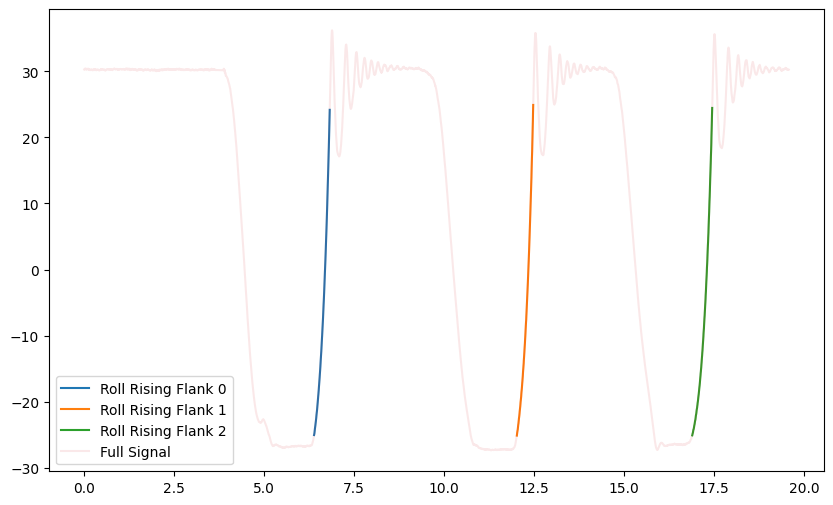

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def detect_rising_flank(signal, max_dips, rise_start_range, rising_end):
    """
    Detect rising flanks in a 1D array/Series allowing up to `max_dips` consecutive non-rising samples,
    and only start rising when the increase exceeds `delta_min`.
    
    Returns a boolean mask of same length as signal.
    """
    count_dips = 0
    rising = False
    rising_start_index = None

    rises = []

    for i in range(1, len(signal)):
        diff = signal[i] - signal[i - 1]

        if rising:
            if signal[i] > rising_end or (diff <= 0 and (count_dips := count_dips + 1) > max_dips):
                rises.append([rising_start_index, i])
                rising = False
                count_dips = 0
            elif diff <= 0:
                count_dips += 1
            else:
                count_dips = 0
        else:
            if signal[i] > rise_start_range[0] and signal[i] <= rise_start_range[1] and diff > 0:
                if (count_dips := count_dips + 1) > max_dips:
                    rising = True
                    rising_start_index = i - count_dips
                    count_dips = 0
            else:
                count_dips = 0

    return rises

# Example usage with CSV
df = pd.read_csv("measurements_roll/measurements_roll_12N_0.2Nm.csv")

# Detect rising flanks on 'roll' column
rises = detect_rising_flank(df["roll_deg"], max_dips=10, rise_start_range=(-15, 0), rising_end=15)

plt.figure(figsize=(10, 6))

for i, rise in enumerate(rises):
    selected_part = df.iloc[rise[0]:rise[1]]
    print(f"Rising flank {i}: from index {rise[0]} to {rise[1]}")

    plt.plot(selected_part["timestamp_iso"], selected_part["roll_deg"], label=f"Roll Rising Flank {i}")

plt.plot(df["timestamp_iso"], df["roll_deg"], alpha=0.1, label="Full Signal")
plt.legend()
plt.show()

Mean Squared Error: -2.96478651753708
Winkelbeschleunigung: 429.8276176067362


<Figure size 1000x600 with 0 Axes>

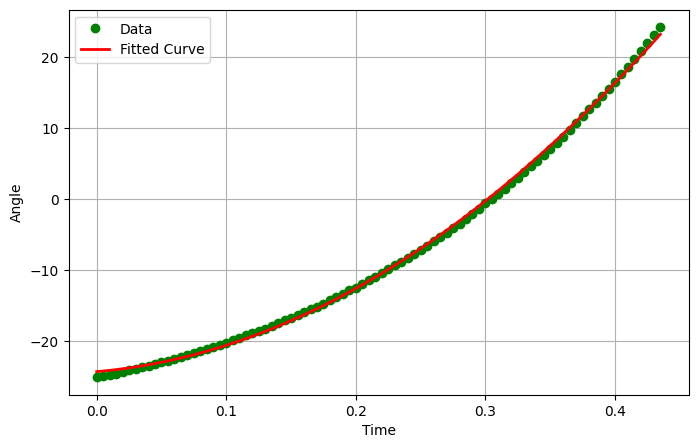

Mean Squared Error: -2.849931221840475
Winkelbeschleunigung: 407.5648111121341


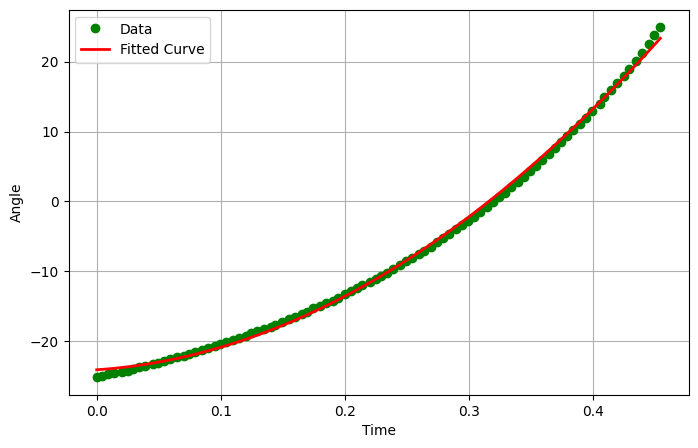

Mean Squared Error: -2.5030466611527102
Winkelbeschleunigung: 319.64140319558174


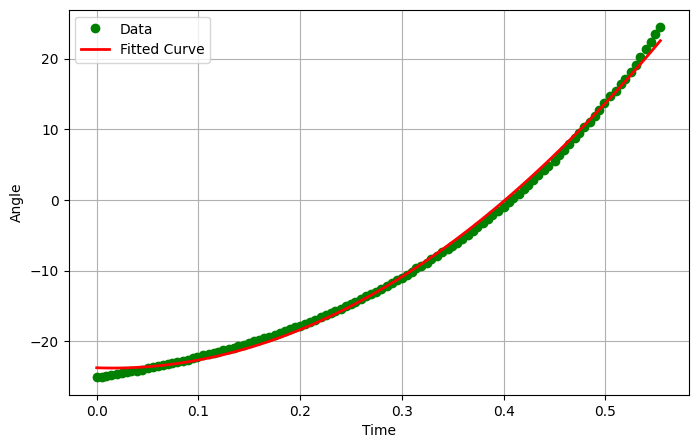

C:\Users\schwmaxi\AppData\Local\Temp\ipykernel_12280\1926899524.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


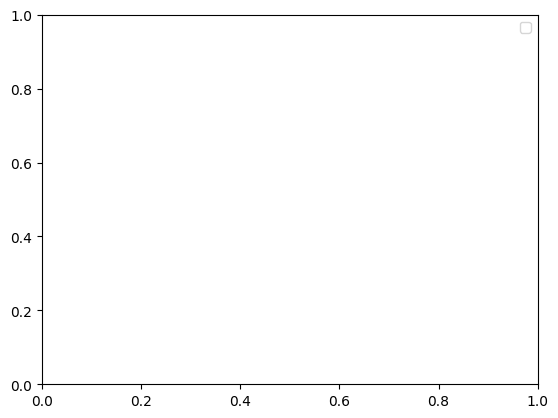

In [25]:
def fit_quadratic(x, y):
    # polynomial fit on selected range
    coeffs = np.polyfit(x, y, 2)

    mse = np.mean(y - np.polyval(coeffs, x)**2) / np.size(y)
    print(f"Mean Squared Error: {mse}")

    print(f"Winkelbeschleunigung: {2 * coeffs[0]}")

    plt.figure(figsize=(8,5))
    plt.plot(x, y, 'go', label='Data')

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = np.polyval(coeffs, x_fit)

    # Plot the quadratic fit
    plt.plot(x_fit, y_fit, 'r-', linewidth=2, label='Fitted Curve')

    plt.xlabel('Time')
    plt.ylabel('Angle')
    plt.legend()
    plt.grid(True)
    plt.show()


plt.figure(figsize=(10, 6))

for i in range(len(rises)):
    selected_part = df.iloc[rises[i][0]:rises[i][1]]

    fit_quadratic(selected_part["timestamp_iso"] - selected_part["timestamp_iso"].iloc[0], selected_part["roll_deg"])

plt.legend()
plt.show()